# Neural Language Model for Next-Word Prediction
### Problem Statement 7 · Penn Treebank Corpus (NLTK)

| | |
|---|---|
| **Group No.** | 67 |
| **Group Members** | *<Name 1 – Roll No.>*, *<Name 2 – Roll No.>*, *<Name 3 – Roll No.>*, *<Name 4 – Roll No.>* |
| **Dataset** | Penn Treebank sample (`nltk.corpus.treebank`) |
| **Framework** | PyTorch |

---

## Objective
Build a **simple neural language model** that predicts the next word from a **fixed window of 3 preceding words**, using an **embedding layer + one fully-connected hidden layer**. The model is trained on the Penn Treebank corpus and evaluated on a held-out, fixed test set.

## Notebook Roadmap
| # | Section | Deliverable covered |
|---|---|---|
| 0 | Setup & Configuration | – |
| 1 | Data Loading & Preprocessing | Data preprocessing |
| 2 | Vocabulary Construction | Vocabulary construction |
| 3 | Sequence Generation | Sequence generation |
| 4 | Neural Language Model | Neural language model |
| 5 | Training | – |
| 6 | Evaluation on the Test Set | Evaluation |
| 7 | Predictions for 10 Test Sequences | ≥ 10 test predictions |
| 8 | Embedding Analysis | Observations |
| 9 | Save Artifacts | – |
| 10 | Observations & Conclusions | Evaluation and observations |

## 0. Setup & Configuration
All hyper-parameters live in **one cell** so that every experiment is reproducible and easy to change.
A fixed random seed makes the train/validation/test split and the training run repeatable.

In [1]:
# ============================================================
# 0.1  Imports
# ============================================================
import os
import json
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import nltk
from sklearn.decomposition import PCA

# Download the Penn Treebank sample (no-op if it is already present)
nltk.download("treebank", quiet=True)
from nltk.corpus import treebank

# Consistent plot style for the whole notebook
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_colwidth", 80)

In [2]:
# ============================================================
# 0.2  Configuration (single source of truth for all settings)
# ============================================================
SEED          = 42        # global random seed
CONTEXT_SIZE  = 3         # REQUIRED: number of preceding words used as input
MIN_FREQ      = 3         # words seen fewer times than this in TRAIN become <UNK>
UNK_TOKEN     = "<UNK>"
REMOVE_TRACES = True      # drop empty "-NONE-" trace tokens such as *-1, *U*, 0

# Model
EMBEDDING_DIM = 128
HIDDEN_SIZE   = 256
DROPOUT       = 0.3

# Optimisation
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
MAX_EPOCHS    = 30
PATIENCE      = 3         # early-stopping patience (epochs) on validation loss

# Data split (by sentence, so no sentence is shared between splits)
TRAIN_FRAC, VAL_FRAC = 0.80, 0.10          # remaining 10 % = test set

In [3]:
# ============================================================
# 0.3  Reproducibility & device
# ============================================================
def set_seed(seed):
    """Seed every random number generator used in this notebook."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version :", torch.__version__)
print("Device          :", device,
      f"({torch.cuda.get_device_name(0)})" if device.type == "cuda" else "")
print("Random seed     :", SEED)

PyTorch version : 2.14.0+cu126
Device          : cuda (NVIDIA GeForce RTX 4050 Laptop GPU)
Random seed     : 42


## 1. Data Loading & Preprocessing

**Steps**
1. Load the Penn Treebank sample from NLTK (3,914 sentences).
2. **Remove trace tokens.** Penn Treebank contains syntactic *empty elements* (tag `-NONE-`) such as `*-1`, `*U*` and `0`. They are annotation artefacts, not real words, and would otherwise pollute the vocabulary and the predictions.
3. **Lowercase** all tokens to shrink the vocabulary and improve generalisation.
4. Drop any sentence that becomes empty.
5. Split **by sentence** into **train (80 %) / validation (10 %) / test (10 %)** with a fixed seed.

> **Why a separate validation set?** The validation set is used for early stopping and learning-rate scheduling. The test set is touched **only once**, at the very end, so the reported test numbers are an unbiased estimate.

In [4]:
# ============================================================
# 1.1  Load the corpus and inspect trace tokens
# ============================================================
tagged_sents = treebank.tagged_sents()          # sentences as (word, POS-tag) pairs

n_sents       = len(tagged_sents)
n_raw_tokens  = sum(len(s) for s in tagged_sents)
n_trace_toks  = sum(1 for s in tagged_sents for _, tag in s if tag == "-NONE-")

print(f"Sentences                 : {n_sents:,}")
print(f"Raw tokens                : {n_raw_tokens:,}")
print(f"Trace tokens (-NONE-)     : {n_trace_toks:,}  ({n_trace_toks / n_raw_tokens:.1%} of all tokens)")

# Show one sentence before / after trace removal
ex_i = next(i for i, s in enumerate(tagged_sents) if any(t == "-NONE-" for _, t in s))
print("\nExample with traces")
print("  raw   :", " ".join(w for w, _ in tagged_sents[ex_i]))
print("  clean :", " ".join(w.lower() for w, t in tagged_sents[ex_i] if t != "-NONE-"))

Sentences                 : 3,914
Raw tokens                : 100,676
Trace tokens (-NONE-)     : 6,592  (6.5% of all tokens)

Example with traces
  raw   : Rudolph Agnew , 55 years old and former chairman of Consolidated Gold Fields PLC , was named *-1 a nonexecutive director of this British industrial conglomerate .
  clean : rudolph agnew , 55 years old and former chairman of consolidated gold fields plc , was named a nonexecutive director of this british industrial conglomerate .


In [5]:
# ============================================================
# 1.2  Text preprocessing: remove traces, lowercase, drop empties
# ============================================================
def normalise(tagged_sentence):
    """Lowercase every token; optionally drop empty '-NONE-' trace tokens."""
    return [w.lower() for w, tag in tagged_sentence
            if not (REMOVE_TRACES and tag == "-NONE-")]

processed = [normalise(s) for s in tagged_sents]
processed = [s for s in processed if len(s) > 0]         # remove empty sentences

lengths = np.array([len(s) for s in processed])
print(f"Sentences after cleaning : {len(processed):,}")
print(f"Tokens after cleaning    : {lengths.sum():,}")
print("Example                  :", " ".join(processed[0]))

Sentences after cleaning : 3,914
Tokens after cleaning    : 94,084
Example                  : pierre vinken , 61 years old , will join the board as a nonexecutive director nov. 29 .


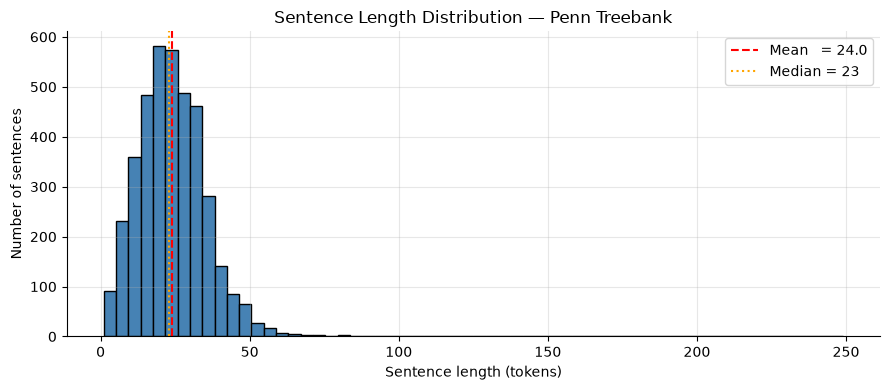

Min = 1,  Max = 249,  sentences shorter than 4 tokens (cannot yield a sequence): 30


In [6]:
# ============================================================
# 1.3  Visualisation: sentence-length distribution
# ============================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=60, color="steelblue", edgecolor="black")
ax.axvline(lengths.mean(),     color="red",    linestyle="--", label=f"Mean   = {lengths.mean():.1f}")
ax.axvline(np.median(lengths), color="orange", linestyle=":",  label=f"Median = {np.median(lengths):.0f}")
ax.set_xlabel("Sentence length (tokens)")
ax.set_ylabel("Number of sentences")
ax.set_title("Sentence Length Distribution — Penn Treebank")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min = {lengths.min()},  Max = {lengths.max()},  "
      f"sentences shorter than {CONTEXT_SIZE + 1} tokens (cannot yield a sequence): {(lengths <= CONTEXT_SIZE).sum()}")

**Observation.** Most sentences contain 15–35 tokens, so a 3-word window sees only a small slice of a typical sentence. Sentences with 3 or fewer tokens cannot produce a (context → target) pair and are skipped later.

In [7]:
# ============================================================
# 1.4  Train / Validation / Test split (by sentence, fixed seed)
# ============================================================
rng = random.Random(SEED)
order = list(range(len(processed)))
rng.shuffle(order)

n_train = int(TRAIN_FRAC * len(order))
n_val   = int(VAL_FRAC   * len(order))

train_sentences = [processed[i] for i in order[:n_train]]
val_sentences   = [processed[i] for i in order[n_train:n_train + n_val]]
test_sentences  = [processed[i] for i in order[n_train + n_val:]]

train_tokens = [t for s in train_sentences for t in s]
val_tokens   = [t for s in val_sentences   for t in s]
test_tokens  = [t for s in test_sentences  for t in s]

split_df = pd.DataFrame({
    "Sentences": [len(train_sentences), len(val_sentences), len(test_sentences)],
    "Tokens":    [len(train_tokens),    len(val_tokens),    len(test_tokens)],
}, index=["Train", "Validation", "Test"])
split_df["Share of tokens"] = (split_df["Tokens"] / split_df["Tokens"].sum()).map("{:.1%}".format)
display(split_df)

,Sentences,Tokens,Share of tokens
Train,3131,75688,80.4%
Validation,391,9046,9.6%
Test,392,9350,9.9%


## 2. Vocabulary Construction

**Rules**
- The vocabulary is built from the **training set only** (no information leaks from validation/test).
- Words appearing fewer than `MIN_FREQ = 3` times are **replaced by `<UNK>`**. This is applied *before* sequence generation, so `<UNK>` also appears as a **training target** and the model learns to predict it. Without this, every unseen word at test time would be a guaranteed error.
- Bidirectional look-ups `word ↔ id` are stored in two dictionaries.

In [8]:
# ============================================================
# 2.1  Build the vocabulary from the training tokens
# ============================================================
word_counts = Counter(train_tokens)

# <UNK> gets id 0, followed by all frequent words in alphabetical order
vocab_words = [UNK_TOKEN] + sorted(w for w, c in word_counts.items() if c >= MIN_FREQ)

word_to_idx = {w: i for i, w in enumerate(vocab_words)}
idx_to_word = {i: w for w, i in word_to_idx.items()}
UNK_ID      = word_to_idx[UNK_TOKEN]
VOCAB_SIZE  = len(word_to_idx)

print(f"Unique words in training set : {len(word_counts):,}")
print(f"Vocabulary size (freq >= {MIN_FREQ}) : {VOCAB_SIZE:,}  (includes {UNK_TOKEN})")
print(f"{UNK_TOKEN} id                       : {UNK_ID}")

Unique words in training set : 9,725
Vocabulary size (freq >= 3) : 3,201  (includes <UNK>)
<UNK> id                       : 0


In [9]:
# ============================================================
# 2.2  Convert tokens to ids and measure the <UNK> rate per split
# ============================================================
def encode(tokens):
    """Map a list of words to ids; rare / unseen words -> UNK_ID."""
    return [word_to_idx.get(w, UNK_ID) for w in tokens]

unk_df = pd.DataFrame({
    "<UNK> rate": [np.mean([i == UNK_ID for i in encode(t)])
                   for t in (train_tokens, val_tokens, test_tokens)]
}, index=["Train", "Validation", "Test"])
unk_df["<UNK> rate"] = unk_df["<UNK> rate"].map("{:.2%}".format)
display(unk_df)

,<UNK> rate
Train,10.62%
Validation,14.55%
Test,13.72%


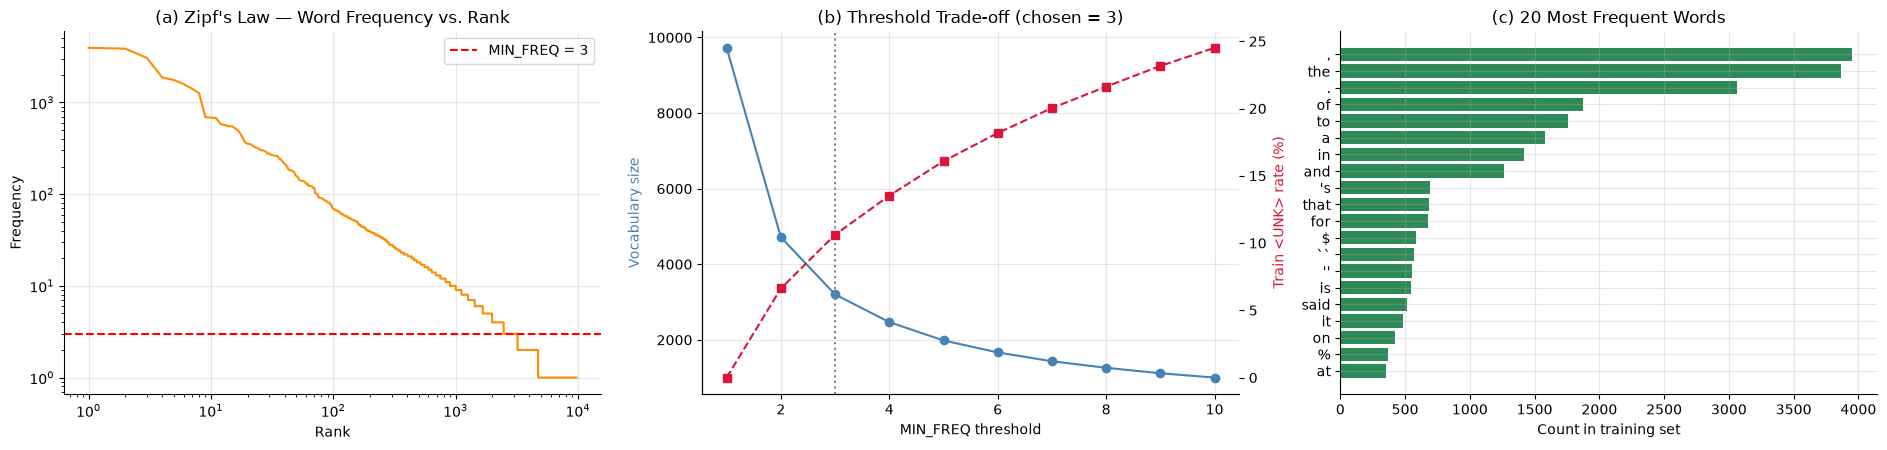

In [10]:
# ============================================================
# 2.3  Visualisations: Zipf's law, MIN_FREQ trade-off, top words
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(19, 4.6))

# (a) Zipf's law: frequency vs. rank on log-log axes
freqs = sorted(word_counts.values(), reverse=True)
axes[0].loglog(range(1, len(freqs) + 1), freqs, color="darkorange")
axes[0].axhline(MIN_FREQ, color="red", linestyle="--", label=f"MIN_FREQ = {MIN_FREQ}")
axes[0].set_xlabel("Rank"); axes[0].set_ylabel("Frequency")
axes[0].set_title("(a) Zipf's Law — Word Frequency vs. Rank")
axes[0].legend()

# (b) How the threshold trades vocabulary size against <UNK> coverage
thresholds = list(range(1, 11))
vocab_sizes = [sum(c >= t for c in word_counts.values()) + 1 for t in thresholds]
unk_rates   = [sum(c for c in word_counts.values() if c < t) / len(train_tokens) for t in thresholds]
axes[1].plot(thresholds, vocab_sizes, "o-", color="steelblue")
axes[1].set_xlabel("MIN_FREQ threshold"); axes[1].set_ylabel("Vocabulary size", color="steelblue")
ax2 = axes[1].twinx()
ax2.plot(thresholds, [u * 100 for u in unk_rates], "s--", color="crimson")
ax2.set_ylabel("Train <UNK> rate (%)", color="crimson"); ax2.grid(False)
axes[1].axvline(MIN_FREQ, color="gray", linestyle=":")
axes[1].set_title("(b) Threshold Trade-off (chosen = %d)" % MIN_FREQ)

# (c) 20 most frequent words
top20 = word_counts.most_common(20)
axes[2].barh([w for w, _ in top20][::-1], [c for _, c in top20][::-1], color="seagreen")
axes[2].set_xlabel("Count in training set")
axes[2].set_title("(c) 20 Most Frequent Words")

plt.tight_layout()
plt.show()

**Observations**
- **(a)** Word frequencies follow **Zipf's law**: a handful of words (`the`, `,`, `.`) dominate while thousands appear only once or twice.
- **(b)** Raising `MIN_FREQ` shrinks the vocabulary (and the size of the output layer) quickly, at the price of more `<UNK>` tokens. `MIN_FREQ = 3` keeps a manageable vocabulary while still covering close to 90 % of training tokens.
- **(c)** Function words and punctuation are the most frequent targets, which explains why even a unigram baseline achieves non-trivial accuracy (compared in Section 6).

## 3. Sequence Generation

A **sliding window of 3 words** moves across every sentence; the word right after the window is the prediction target:

```
sentence : w0  w1  w2  w3  w4  w5 ...
window 1 : [w0  w1  w2]  →  w3
window 2 :     [w1  w2  w3]  →  w4
window 3 :         [w2  w3  w4]  →  w5
```
Windows never cross sentence boundaries. Raw words are kept alongside the ids so predictions can later be shown in readable form.

In [11]:
# ============================================================
# 3.1  Sliding-window sequence generation (context = 3 words)
# ============================================================
def make_windows(sentences, ctx=CONTEXT_SIZE):
    """Return a list of (context_words, target_word) pairs for every sentence."""
    windows = []
    for sent in sentences:
        for i in range(len(sent) - ctx):            # empty range if sentence is too short
            windows.append((sent[i:i + ctx], sent[i + ctx]))
    return windows

def encode_windows(windows):
    """Convert (context_words, target_word) pairs into id tensors X [N, ctx], y [N]."""
    X = torch.tensor([[word_to_idx.get(w, UNK_ID) for w in c] for c, _ in windows], dtype=torch.long)
    y = torch.tensor([word_to_idx.get(t, UNK_ID) for _, t in windows], dtype=torch.long)
    return X, y

train_windows = make_windows(train_sentences)
val_windows   = make_windows(val_sentences)
test_windows  = make_windows(test_sentences)

X_train, y_train = encode_windows(train_windows)
X_val,   y_val   = encode_windows(val_windows)
X_test,  y_test  = encode_windows(test_windows)

shape_df = pd.DataFrame({
    "# Sequences": [len(X_train), len(X_val), len(X_test)],
    "X shape":     [tuple(X_train.shape), tuple(X_val.shape), tuple(X_test.shape)],
    "y shape":     [tuple(y_train.shape), tuple(y_val.shape), tuple(y_test.shape)],
}, index=["Train", "Validation", "Test"])
display(shape_df)

,# Sequences,X shape,y shape
Train,66312,"(66312, 3)","(66312,)"
Validation,7874,"(7874, 3)","(7874,)"
Test,8177,"(8177, 3)","(8177,)"


In [12]:
# ============================================================
# 3.2  Inspect a few generated sequences (words and their ids)
# ============================================================
rows = []
for k in range(8):
    ctx_words, target = train_windows[k]
    rows.append({
        "Context (3 words)": " | ".join(ctx_words),
        "Context ids":       X_train[k].tolist(),
        "Target word":       target if target in word_to_idx else f"{target}  →  {UNK_TOKEN}",
        "Target id":         y_train[k].item(),
    })
display(pd.DataFrame(rows))

,Context (3 words),Context ids,Target word,Target id
0,the | company | noted,"[2891, 693, 1986]",that,2890
1,company | noted | that,"[693, 1986, 2890]",it,1585
2,noted | that | it,"[1986, 2890, 1585]",has,1401
3,that | it | has,"[2890, 1585, 1401]",reduced,2388
4,it | has | reduced,"[1585, 1401, 2388]",debt,861
5,has | reduced | debt,"[1401, 2388, 861]",by,549
6,reduced | debt | by,"[2388, 861, 549]",$,3
7,debt | by | $,"[861, 549, 3]",1.6 → <UNK>,0


In [13]:
# ============================================================
# 3.3  Wrap tensors in DataLoaders
# ============================================================
g = torch.Generator().manual_seed(SEED)            # reproducible shuffling

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches per epoch -> train: {len(train_loader)},  validation: {len(val_loader)},  test: {len(test_loader)}")

Batches per epoch -> train: 1037,  validation: 124,  test: 128


## 4. Neural Language Model

The architecture follows the problem statement exactly: **an embedding layer and one fully-connected hidden layer**, followed by the output projection onto the vocabulary.

| Layer | Shape | Purpose |
|---|---|---|
| Input | `[B, 3]` | ids of the 3 preceding words |
| **Embedding** | `[B, 3, 128]` | dense vector per word (learned) |
| Flatten | `[B, 384]` | concatenate the three word vectors |
| **Hidden FC + ReLU** | `[B, 256]` | the single hidden layer |
| Dropout (0.3) | `[B, 256]` | regularisation (adds no layer) |
| Output FC | `[B, V]` | one logit per vocabulary word |

`CrossEntropyLoss` applies the softmax internally, so the model returns raw **logits**.

In [14]:
# ============================================================
# 4.1  Model definition
# ============================================================
class NeuralLanguageModel(nn.Module):
    """
    Feed-forward neural language model for next-word prediction.

        3 word ids -> Embedding -> Flatten -> Linear(hidden) -> ReLU
                   -> Dropout -> Linear(vocab)  (logits)
    """

    def __init__(self, vocab_size, embedding_dim, hidden_size, context_size, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)               # word id -> vector
        self.fc1       = nn.Linear(context_size * embedding_dim, hidden_size)  # the ONE hidden layer
        self.dropout   = nn.Dropout(dropout)                                   # regularisation only
        self.fc2       = nn.Linear(hidden_size, vocab_size)                    # output projection

    def forward(self, x):
        emb = self.embedding(x)              # [B, C]    -> [B, C, D]
        emb = emb.flatten(start_dim=1)       # [B, C, D] -> [B, C*D]
        h   = torch.relu(self.fc1(emb))      # [B, C*D]  -> [B, H]
        h   = self.dropout(h)
        return self.fc2(h)                   # [B, H]    -> [B, V]  (logits)

model = NeuralLanguageModel(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, CONTEXT_SIZE, DROPOUT).to(device)
print(model)

NeuralLanguageModel(
  (embedding): Embedding(3201, 128)
  (fc1): Linear(in_features=384, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=3201, bias=True)
)


In [15]:
# ============================================================
# 4.2  Parameter count per layer
# ============================================================
param_df = pd.DataFrame({
    "Parameters": {name: sum(p.numel() for p in m.parameters())
                   for name, m in model.named_children() if sum(p.numel() for p in m.parameters()) > 0}
})
param_df.loc["TOTAL"] = param_df["Parameters"].sum()
param_df["Share"] = (param_df["Parameters"] / param_df.loc["TOTAL", "Parameters"]).map("{:.1%}".format)
display(param_df.style.format({"Parameters": "{:,}"}))

,Parameters,Share
embedding,"409,728",30.8%
fc1,"98,560",7.4%
fc2,"822,657",61.8%
TOTAL,"1,330,945",100.0%


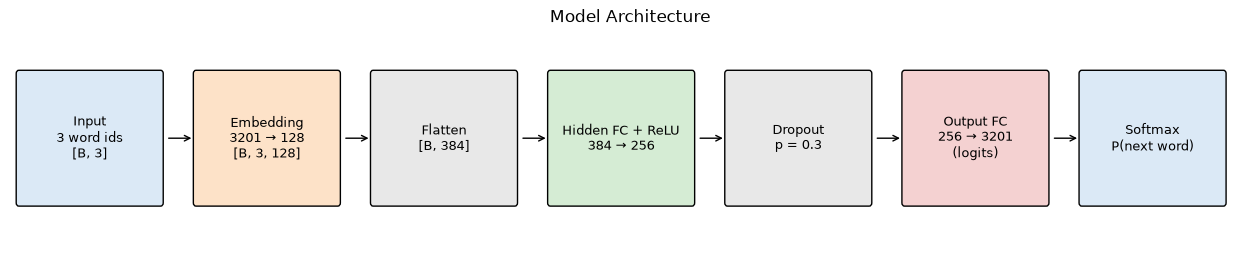

In [16]:
# ============================================================
# 4.3  Architecture diagram
# ============================================================
def draw_architecture():
    blocks = [
        (f"Input\n{CONTEXT_SIZE} word ids\n[B, {CONTEXT_SIZE}]",                       "#dbe9f6"),
        (f"Embedding\n{VOCAB_SIZE} → {EMBEDDING_DIM}\n[B, {CONTEXT_SIZE}, {EMBEDDING_DIM}]", "#fde2c8"),
        (f"Flatten\n[B, {CONTEXT_SIZE * EMBEDDING_DIM}]",                              "#e8e8e8"),
        (f"Hidden FC + ReLU\n{CONTEXT_SIZE * EMBEDDING_DIM} → {HIDDEN_SIZE}",          "#d5ecd4"),
        (f"Dropout\np = {DROPOUT}",                                                    "#e8e8e8"),
        (f"Output FC\n{HIDDEN_SIZE} → {VOCAB_SIZE}\n(logits)",                         "#f4d1d1"),
        ("Softmax\nP(next word)",                                                      "#dbe9f6"),
    ]
    fig, ax = plt.subplots(figsize=(16, 2.8))
    ax.axis("off"); ax.set_xlim(0, 2 * len(blocks)); ax.set_ylim(0, 2)
    for k, (label, colour) in enumerate(blocks):
        x = 2 * k + 0.1
        ax.add_patch(FancyBboxPatch((x, 0.4), 1.6, 1.2, boxstyle="round,pad=0.03", fc=colour, ec="black"))
        ax.text(x + 0.8, 1.0, label, ha="center", va="center", fontsize=9)
        if k < len(blocks) - 1:
            ax.annotate("", xy=(x + 1.98, 1.0), xytext=(x + 1.66, 1.0), arrowprops=dict(arrowstyle="->"))
    ax.set_title("Model Architecture", fontsize=12)
    plt.show()

draw_architecture()

## 5. Training

| Setting | Value | Reason |
|---|---|---|
| Loss | Cross-entropy | standard for multi-class prediction |
| Optimiser | Adam (`lr = 1e-3`, `weight_decay = 1e-4`) | fast convergence, L2 regularisation |
| Scheduler | `ReduceLROnPlateau` (×0.5 after 2 stalled epochs) | smaller steps near the optimum |
| **Early stopping** | patience = 3 on **validation** loss | stop before over-fitting |
| **Checkpointing** | best validation epoch is restored | final model = best model, not last model |

Only the **training** and **validation** sets are used here. The test set is untouched.

In [17]:
# ============================================================
# 5.1  Training / evaluation helper
# ============================================================
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None):
    """
    One pass over `loader`.
    - optimizer given  -> training mode (weights are updated)
    - optimizer is None -> evaluation mode (no gradients)
    Returns (average loss per token, top-1 accuracy).
    """
    training = optimizer is not None
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(training):
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * yb.size(0)        # weight by batch size
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += yb.size(0)

    return total_loss / n, correct / n

In [18]:
# ============================================================
# 5.2  Training loop with early stopping and best-model checkpoint
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val_loss, best_epoch, best_state, wait = float("inf"), 0, None, 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)     # update weights
    va_loss, va_acc = run_epoch(model, val_loader)                  # validate
    scheduler.step(va_loss)

    for key, val in zip(history, (tr_loss, va_loss, tr_acc, va_acc, optimizer.param_groups[0]["lr"])):
        history[key].append(val)

    # Keep a copy of the weights whenever validation loss improves
    improved = va_loss < best_val_loss - 1e-4
    if improved:
        best_val_loss, best_epoch, wait = va_loss, epoch, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f} | lr {history['lr'][-1]:.1e}"
          + ("  <- best" if improved else ""))

    if wait >= PATIENCE:
        print(f"\nEarly stopping: no validation improvement for {PATIENCE} epochs.")
        break

model.load_state_dict(best_state)                                  # restore the best weights
print(f"Restored best model from epoch {best_epoch} (val loss {best_val_loss:.4f}).")

Epoch 01 | train loss 5.712 acc 0.133 | val loss 5.152 acc 0.178 | lr 1.0e-03  <- best
Epoch 02 | train loss 5.090 acc 0.169 | val loss 4.969 acc 0.191 | lr 1.0e-03  <- best
Epoch 03 | train loss 4.765 acc 0.185 | val loss 4.865 acc 0.204 | lr 1.0e-03  <- best
Epoch 04 | train loss 4.528 acc 0.198 | val loss 4.837 acc 0.208 | lr 1.0e-03  <- best
Epoch 05 | train loss 4.340 acc 0.209 | val loss 4.791 acc 0.216 | lr 1.0e-03  <- best
Epoch 06 | train loss 4.177 acc 0.220 | val loss 4.786 acc 0.220 | lr 1.0e-03  <- best
Epoch 07 | train loss 4.038 acc 0.228 | val loss 4.795 acc 0.217 | lr 1.0e-03
Epoch 08 | train loss 3.919 acc 0.237 | val loss 4.783 acc 0.228 | lr 1.0e-03  <- best
Epoch 09 | train loss 3.798 acc 0.247 | val loss 4.797 acc 0.222 | lr 1.0e-03
Epoch 10 | train loss 3.691 acc 0.254 | val loss 4.808 acc 0.224 | lr 1.0e-03
Epoch 11 | train loss 3.595 acc 0.263 | val loss 4.814 acc 0.219 | lr 5.0e-04

Early stopping: no validation improvement for 3 epochs.
Restored best model fr

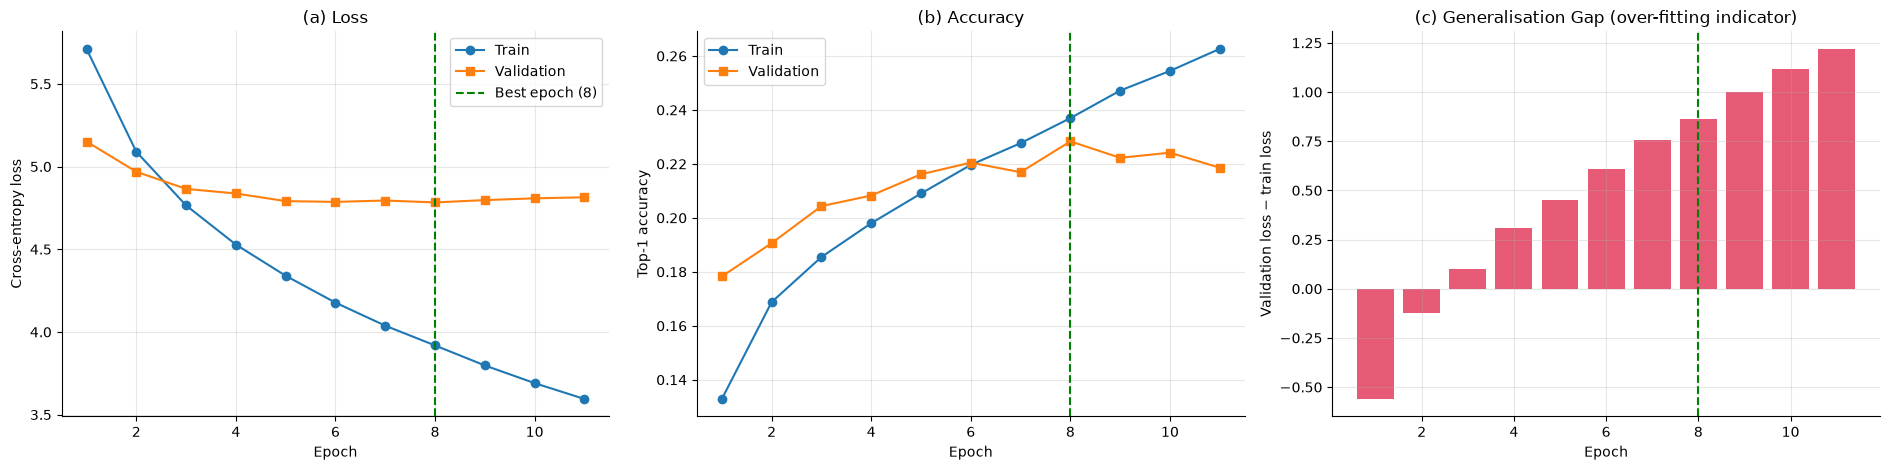

In [19]:
# ============================================================
# 5.3  Training curves
# ============================================================
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))

# (a) Loss
axes[0].plot(epochs, history["train_loss"], "o-", label="Train")
axes[0].plot(epochs, history["val_loss"],   "s-", label="Validation")
axes[0].axvline(best_epoch, color="green", linestyle="--", label=f"Best epoch ({best_epoch})")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("(a) Loss"); axes[0].legend()

# (b) Accuracy
axes[1].plot(epochs, history["train_acc"], "o-", label="Train")
axes[1].plot(epochs, history["val_acc"],   "s-", label="Validation")
axes[1].axvline(best_epoch, color="green", linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Top-1 accuracy")
axes[1].set_title("(b) Accuracy"); axes[1].legend()

# (c) Generalisation gap = validation loss - train loss
gap = np.array(history["val_loss"]) - np.array(history["train_loss"])
axes[2].bar(epochs, gap, color="crimson", alpha=0.7)
axes[2].axvline(best_epoch, color="green", linestyle="--")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Validation loss − train loss")
axes[2].set_title("(c) Generalisation Gap (over-fitting indicator)")

plt.tight_layout()
plt.show()

**How to read these curves**
- **(a)** Training loss keeps falling, while validation loss flattens and eventually turns upward — the classic sign of **over-fitting**. The dashed green line marks the epoch whose weights were kept.
- **(b)** Training accuracy keeps climbing, but validation accuracy saturates. (Training accuracy is measured with dropout active, so it is slightly pessimistic.)
- **(c)** The gap between validation and training loss widens with every epoch, which justifies early stopping.

## 6. Evaluation on the Test Set

The test set is now used **once**. Metrics reported:

- **Test loss** – average negative log-likelihood per predicted word.
- **Perplexity** = `exp(loss)`; interpretable as the model's *effective number of equally-likely candidates* per word (lower is better).
- **Top-1 / Top-5 accuracy** – is the true word the best guess / among the 5 best guesses?
- **Accuracy excluding `<UNK>` targets** – `<UNK>` stands for many different rare words, so predicting it is not a *real* word prediction; this shows performance on actual words.
- **Unigram baseline** – a model that ignores the context and always uses corpus word frequencies, to prove the network learns context.

In [20]:
# ============================================================
# 6.1  Score every test sequence (top-5 predictions + per-sample loss)
# ============================================================
@torch.no_grad()
def predict_all(model, X, y, batch_size=1024):
    """Return top-5 predicted ids [N, 5] and negative log-likelihood per sample [N]."""
    model.eval()
    top5, nll = [], []
    for i in range(0, len(X), batch_size):
        logits = model(X[i:i + batch_size].to(device))
        nll.append(F.cross_entropy(logits, y[i:i + batch_size].to(device), reduction="none").cpu())
        top5.append(logits.topk(5, dim=1).indices.cpu())
    return torch.cat(top5).numpy(), torch.cat(nll).numpy()

test_top5, test_nll = predict_all(model, X_test, y_test)
y_np = y_test.numpy()

hit1 = test_top5[:, 0] == y_np
hit5 = (test_top5 == y_np[:, None]).any(axis=1)
known = y_np != UNK_ID                                     # mask: target is a real (non-UNK) word

# --- Unigram (context-free) baseline, add-one smoothed on training targets ---
target_counts = torch.bincount(y_train, minlength=VOCAB_SIZE).float() + 1
unigram_p     = target_counts / target_counts.sum()
unigram_ppl   = math.exp(-torch.log(unigram_p[y_test]).mean().item())
majority_word = idx_to_word[unigram_p.argmax().item()]
majority_acc  = (y_np == unigram_p.argmax().item()).mean()

test_loss = test_nll.mean()
test_ppl  = math.exp(test_loss)

results = pd.DataFrame({
    "Neural LM":         [test_loss, test_ppl, hit1.mean(), hit5.mean(), hit1[known].mean(), hit5[known].mean()],
    "Unigram baseline":  [-torch.log(unigram_p[y_test]).mean().item(), unigram_ppl, majority_acc, np.nan, np.nan, np.nan],
}, index=["Test loss", "Perplexity", "Top-1 accuracy", "Top-5 accuracy",
          "Top-1 acc. (excl. <UNK> targets)", "Top-5 acc. (excl. <UNK> targets)"])
display(results.style.format("{:.4f}", na_rep="–"))
print(f"Unigram baseline always predicts: '{majority_word}'")
print(f"Share of test targets that are {UNK_TOKEN}: {(~known).mean():.2%}")

,Neural LM,Unigram baseline
Test loss,4.7408,5.6707
Perplexity,114.5223,290.2487
Top-1 accuracy,0.2277,0.1379
Top-5 accuracy,0.4591,–
Top-1 acc. (excl. targets),0.1600,–
Top-5 acc. (excl. targets),0.3809,–


Unigram baseline always predicts: '<UNK>'
Share of test targets that are <UNK>: 13.79%


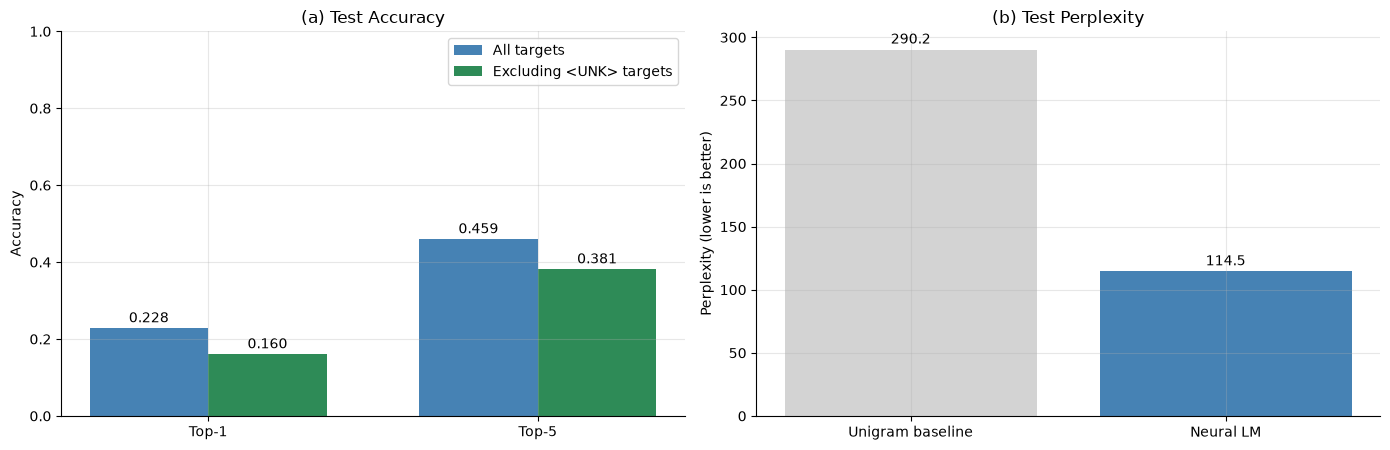

In [21]:
# ============================================================
# 6.2  Visualisation: accuracy and perplexity vs. baseline
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

# (a) Top-1 / Top-5 accuracy, all targets vs. excluding <UNK>
labels = ["Top-1", "Top-5"]
all_t  = [hit1.mean(), hit5.mean()]
known_t = [hit1[known].mean(), hit5[known].mean()]
x = np.arange(2); w = 0.36
b1 = axes[0].bar(x - w/2, all_t,   w, label="All targets",         color="steelblue")
b2 = axes[0].bar(x + w/2, known_t, w, label="Excluding <UNK> targets", color="seagreen")
axes[0].bar_label(b1, fmt="%.3f", padding=2)
axes[0].bar_label(b2, fmt="%.3f", padding=2)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Accuracy")
axes[0].set_title("(a) Test Accuracy"); axes[0].legend()

# (b) Perplexity: neural model vs. unigram baseline (lower is better)
b3 = axes[1].bar(["Unigram baseline", "Neural LM"], [unigram_ppl, test_ppl], color=["lightgray", "steelblue"])
axes[1].bar_label(b3, fmt="%.1f", padding=2)
axes[1].set_ylabel("Perplexity (lower is better)")
axes[1].set_title("(b) Test Perplexity")

plt.tight_layout()
plt.show()

,# test targets,Share of test set,Top-1 accuracy,Top-5 accuracy
Target bucket,,,,
Top 10,2235,27.3%,34.0%,80.1%
Rank 11-100,1804,22.1%,15.2%,36.3%
Rank 101-1000,2019,24.7%,4.5%,10.5%
Rank >1000,991,12.1%,0.4%,2.8%
,1128,13.8%,65.1%,94.8%


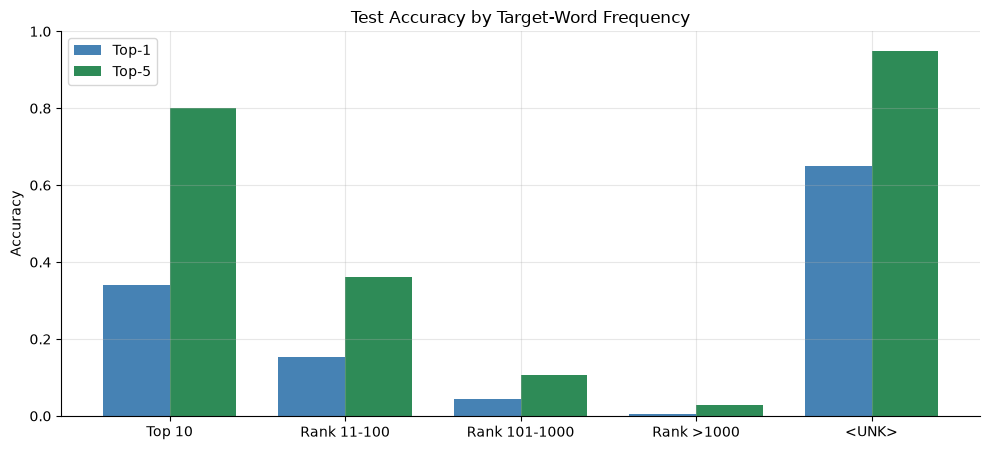

In [22]:
# ============================================================
# 6.3  Error analysis by target-word frequency
#      Are frequent words easier to predict than rare ones?
# ============================================================
# Rank of every vocabulary word by training frequency (1 = most frequent)
ranked = sorted((w for w in vocab_words if w != UNK_TOKEN), key=lambda w: -word_counts[w])
rank_of = {w: r for r, w in enumerate(ranked, start=1)}

BUCKETS = ["Top 10", "Rank 11-100", "Rank 101-1000", "Rank >1000", UNK_TOKEN]
def bucket(word_id):
    if word_id == UNK_ID:
        return UNK_TOKEN
    r = rank_of[idx_to_word[word_id]]
    return "Top 10" if r <= 10 else "Rank 11-100" if r <= 100 else "Rank 101-1000" if r <= 1000 else "Rank >1000"

buckets = np.array([bucket(i) for i in y_np])
rows = []
for b in BUCKETS:
    m = buckets == b
    rows.append({"Target bucket": b, "# test targets": int(m.sum()), "Share of test set": m.mean(),
                 "Top-1 accuracy": hit1[m].mean(), "Top-5 accuracy": hit5[m].mean()})
bucket_df = pd.DataFrame(rows).set_index("Target bucket")
display(bucket_df.style.format({"Share of test set": "{:.1%}", "Top-1 accuracy": "{:.1%}", "Top-5 accuracy": "{:.1%}"}))

# Plot
x = np.arange(len(BUCKETS)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(x - w/2, bucket_df["Top-1 accuracy"], w, label="Top-1", color="steelblue")
ax.bar(x + w/2, bucket_df["Top-5 accuracy"], w, label="Top-5", color="seagreen")
ax.set_xticks(x); ax.set_xticklabels(BUCKETS)
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1)
ax.set_title("Test Accuracy by Target-Word Frequency")
ax.legend()
plt.tight_layout(); plt.show()

In [23]:
# ============================================================
# 6.4  Most frequent mistakes (actual word vs. top-1 prediction)
# ============================================================
wrong = ~hit1
mistakes = Counter((idx_to_word[a], idx_to_word[p]) for a, p in zip(y_np[wrong], test_top5[wrong, 0]))
mistake_df = pd.DataFrame([{"Actual": a, "Predicted": p, "Count": c} for (a, p), c in mistakes.most_common(10)])
display(mistake_df)

,Actual,Predicted,Count
0,<UNK>,the,126
1,.,",",122
2,the,<UNK>,98
3,<UNK>,",",80
4,",",.,77
5,",",<UNK>,66
6,a,<UNK>,63
7,a,the,57
8,of,<UNK>,50
9,.,<UNK>,50


## 7. Predictions for 10 Test Sequences

Ten sequences are drawn **at random (fixed seed) from the whole test set**, so they come from different sentences and are not just the first few overlapping windows. Contexts are shown with the **original words** (before `<UNK>` replacement).

Colour legend:  🟩 top-1 correct  ·  🟨 correct only within top-5  ·  🟥 not in top-5

In [24]:
# ============================================================
# 7.1  Prediction helper for arbitrary 3-word contexts
# ============================================================
def predict_next_word(context_words, top_k=5):
    """Given exactly 3 words, return (best_word, [(word, probability), ...])."""
    assert len(context_words) == CONTEXT_SIZE, f"Need exactly {CONTEXT_SIZE} context words."

    ids = [word_to_idx.get(w.lower(), UNK_ID) for w in context_words]     # unseen word -> <UNK>
    x   = torch.tensor([ids], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0]

    top_p, top_i = probs.topk(top_k)
    preds = [(idx_to_word[i.item()], p.item()) for p, i in zip(top_p, top_i)]
    return preds[0][0], preds

In [25]:
# ============================================================
# 7.2  Randomly sample 10 test sequences and predict
# ============================================================
sample_idx = random.Random(SEED).sample(range(len(test_windows)), 10)
eval_sequences = [test_windows[i] for i in sample_idx]

rows = []
for ctx, actual in eval_sequences:
    best, top5 = predict_next_word(ctx, top_k=5)
    top5_words = [w for w, _ in top5]
    rows.append({
        "Context":           " ".join(ctx),
        "Actual":            actual,
        "Top-1 Prediction":  best,
        "Confidence":        f"{top5[0][1]:.1%}",
        "Top-5 Predictions": ", ".join(top5_words),
        "Top-1 Correct":     best == actual,
        "Top-5 Correct":     actual in top5_words,
    })
pred_df = pd.DataFrame(rows)

def colour_row(row):
    c = "#d4edda" if row["Top-1 Correct"] else "#fff3cd" if row["Top-5 Correct"] else "#f8d7da"
    return [f"background-color: {c}; color: black"] * len(row)

display(pred_df.style.apply(colour_row, axis=1))
print(f"Top-1 accuracy on these 10 sequences: {pred_df['Top-1 Correct'].mean():.0%}")
print(f"Top-5 accuracy on these 10 sequences: {pred_df['Top-5 Correct'].mean():.0%}")

,Context,Actual,Top-1 Prediction,Confidence,Top-5 Predictions,Top-1 Correct,Top-5 Correct
0,may have single-handedly,turned,,15.8%,", the, ., a, about",False,False
1,chauffeur who offers,the,the,25.0%,"the, to, a, ., that",True,True
2,becomes too volatile,.,.,19.4%,"., ,, to, in, for",True,True
3,has many ways,to,to,69.1%,"to, of, for, in,",True,True
4,into production before,the,the,22.4%,"the, , ., they, ,",True,True
5,`` clouds of,blue,,17.9%,", the, these, its, a",False,False
6,when each will,adopt,be,22.6%,"be, , receive, become, have",False,False
7,pay movie producers,for,.,4.6%,"., in, , to, for",False,True
8,region than the,u.s.,,12.2%,", u.s., same, country, company",False,True
9,case of political,corruption,,77.5%,", ., ,, u.s., a",False,False


Top-1 accuracy on these 10 sequences: 40%
Top-5 accuracy on these 10 sequences: 60%


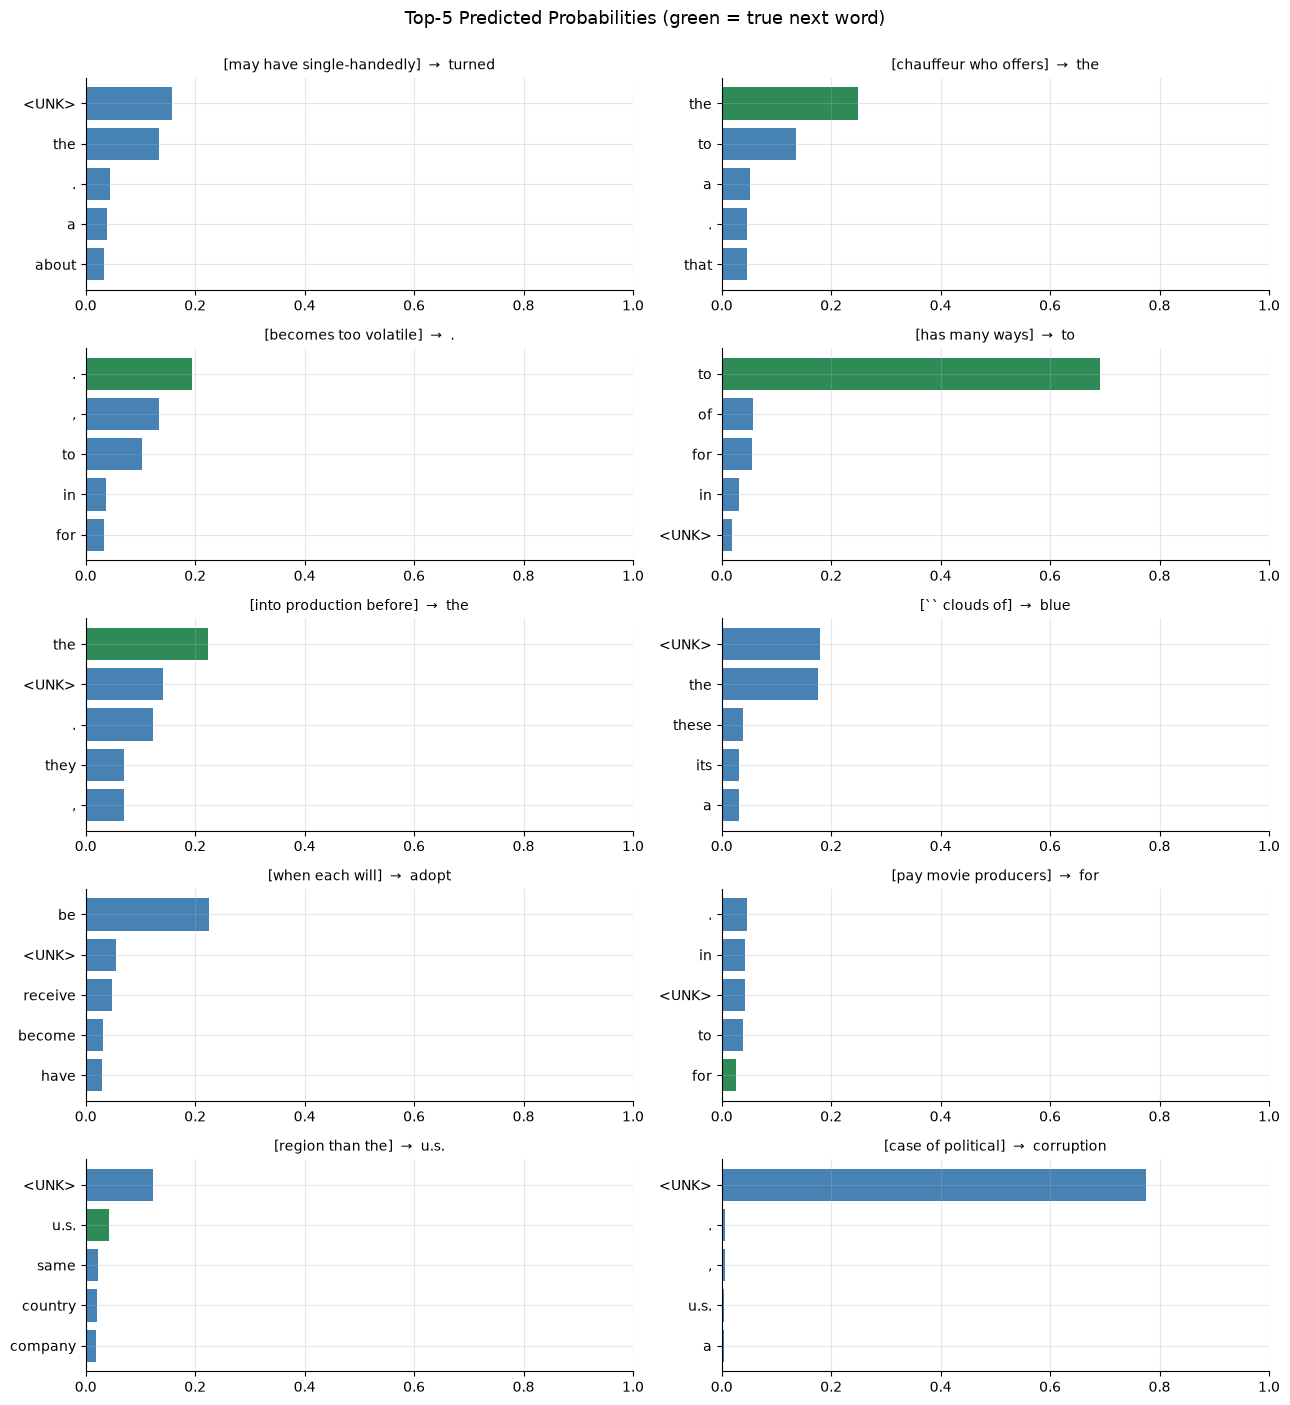

In [26]:
# ============================================================
# 7.3  Visualise the top-5 probability distribution of each prediction
# ============================================================
fig, axes = plt.subplots(5, 2, figsize=(13, 14))
for ax, (ctx, actual) in zip(axes.ravel(), eval_sequences):
    _, top5 = predict_next_word(ctx, top_k=5)
    words  = [w for w, _ in top5][::-1]                      # reversed so best is on top
    probs  = [p for _, p in top5][::-1]
    colors = ["seagreen" if w == actual else "steelblue" for w in words]
    ax.barh(words, probs, color=colors)
    ax.set_xlim(0, 1)
    ctx_str = " ".join(ctx)
    ax.set_title(f"[{ctx_str}]  →  {actual}", fontsize=10)
fig.suptitle("Top-5 Predicted Probabilities (green = true next word)", fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 7.4  Try your own contexts and generate a short continuation
# ============================================================
demo_contexts = [["the", "company", "said"], ["stock", "market", "prices"],
                 ["he", "is", "the"],       ["in", "new", "york"]]

for ctx in demo_contexts:
    best, top3 = predict_next_word(ctx, top_k=3)
    print(f"{' '.join(ctx):<22} ->  " + ",  ".join(f"{w} ({p:.1%})" for w, p in top3))

def generate_text(seed_words, n_words=12, temperature=0.8):
    """Repeatedly predict the next word (sampling with a temperature) to extend the seed."""
    gen = torch.Generator().manual_seed(SEED)
    words = list(seed_words)
    model.eval()
    for _ in range(n_words):
        ids = [word_to_idx.get(w, UNK_ID) for w in words[-CONTEXT_SIZE:]]
        with torch.no_grad():
            logits = model(torch.tensor([ids], device=device))[0] / temperature
        probs = torch.softmax(logits, dim=0).cpu()
        probs[UNK_ID] = 0                                        # never sample <UNK>
        words.append(idx_to_word[torch.multinomial(probs / probs.sum(), 1, generator=gen).item()])
    return " ".join(words)

print("\nGenerated text (for illustration only):")
for seed in (["the", "company", "said"], ["shares", "of", "the"]):
    print("  ", generate_text(seed))

the company said       ->  it (45.1%),  . (20.1%),  that (7.5%)
stock market prices    ->  <UNK> (25.8%),  , (10.3%),  . (8.9%)
he is the              ->  <UNK> (24.5%),  very (4.7%),  one (4.3%)
in new york            ->  stock (46.7%),  . (15.7%),  , (8.3%)

Generated text (for illustration only):
   the company said it decided to win them . '' -lrb- except to scrutiny into
   shares of the same transplant defense general manager , '' says the company 's net


## 8. Embedding Analysis

The embedding layer learns a vector for every word purely from next-word prediction. If training worked, words used in similar contexts should end up **close together**. We check this two ways:
1. A **2-D PCA projection** of the 60 most frequent words, coloured by word type.
2. **Nearest neighbours** by cosine similarity for a few example words.

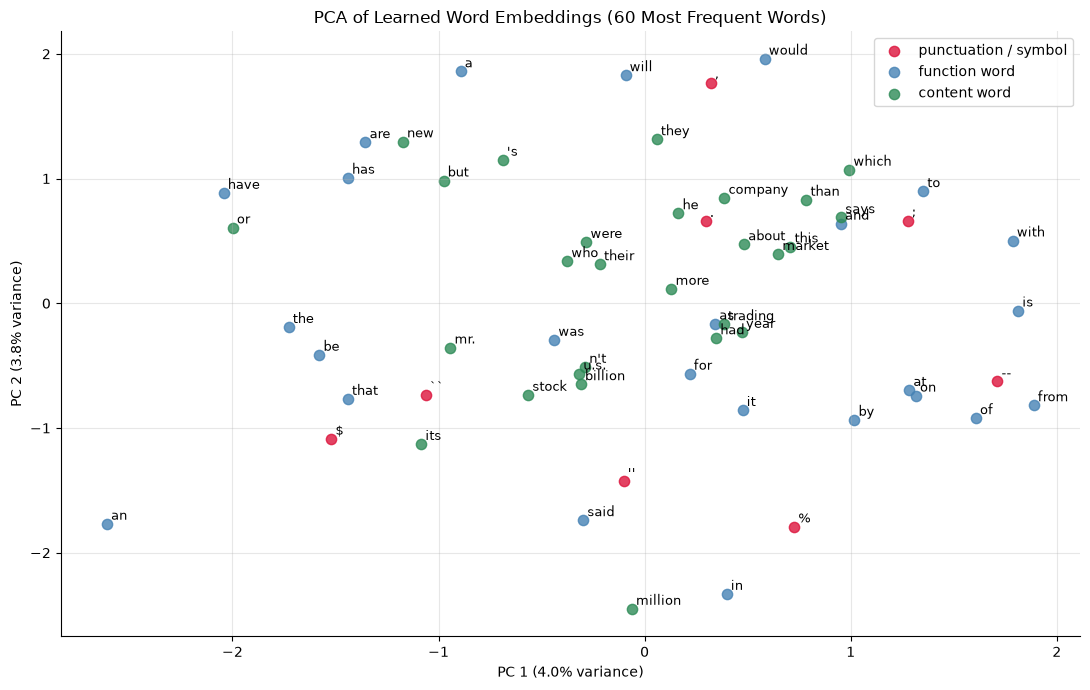

In [28]:
# ============================================================
# 8.1  PCA projection of learned embeddings, coloured by word type
# ============================================================
emb = model.embedding.weight.detach().cpu().numpy()

FUNCTION_WORDS = {"the", "a", "an", "of", "to", "in", "and", "for", "that", "is", "on", "by", "with",
                  "as", "at", "from", "it", "was", "has", "have", "will", "would", "said", "are", "be"}
def word_type(w):
    if not any(ch.isalnum() for ch in w): return "punctuation / symbol"
    if any(ch.isdigit() for ch in w):     return "number"
    if w in FUNCTION_WORDS:               return "function word"
    return "content word"

top_words = [w for w, _ in word_counts.most_common(80) if w in word_to_idx][:60]
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(emb[[word_to_idx[w] for w in top_words]])

palette = {"punctuation / symbol": "crimson", "number": "darkorange",
           "function word": "steelblue", "content word": "seagreen"}
fig, ax = plt.subplots(figsize=(11, 7))
for wtype, colour in palette.items():
    pts = [(c, w) for c, w in zip(coords, top_words) if word_type(w) == wtype]
    if pts:
        ax.scatter([p[0][0] for p in pts], [p[0][1] for p in pts], color=colour, label=wtype, s=55, alpha=0.8)
        for c, w in pts:
            ax.annotate(w, c, fontsize=9, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA of Learned Word Embeddings (60 Most Frequent Words)")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# 8.2  Nearest neighbours in embedding space (cosine similarity)
# ============================================================
emb_unit = emb / np.linalg.norm(emb, axis=1, keepdims=True)

def nearest_words(word, k=5):
    """Return the k words whose embedding is most similar to `word`."""
    sims = emb_unit @ emb_unit[word_to_idx[word]]
    best = np.argsort(-sims)[1:k + 1]                # index 0 is the word itself
    return ", ".join(f"{idx_to_word[i]} ({sims[i]:.2f})" for i in best)

query_words = [w for w in ["company", "million", "said", "year", "market", "president", "u.s."] if w in word_to_idx]
display(pd.DataFrame({"Word": query_words, "Nearest neighbours (cosine)": [nearest_words(w) for w in query_words]}))

,Word,Nearest neighbours (cosine)
0,company,"equitable (0.37), amendment (0.36), minivans (0.33), temple (0.32), britain ..."
1,million,"metric (0.45), green (0.38), little (0.33), one-time (0.31), increased (0.30)"
2,said,"saying (0.43), minute (0.36), shows (0.34), know (0.32), indicated (0.32)"
3,year,"weeks (0.35), switzerland (0.32), ! (0.29), 3\/4 (0.29), georgia-pacific (0.27)"
4,market,"economic (0.27), nasdaq (0.27), harvest (0.27), city (0.26), johnson (0.25)"
5,president,"chairman (0.35), friends (0.31), time (0.29), editor (0.27), electricity (0.27)"
6,u.s.,"u.k. (0.33), confidence (0.31), ms. (0.31), attract (0.30), six-month (0.29)"


## 9. Save Artifacts
The trained weights, the vocabulary and the test predictions are stored in an `artifacts/` folder so the model can be reloaded without retraining.

In [30]:
# ============================================================
# 9.1  Save model weights, vocabulary, configuration and predictions
# ============================================================
os.makedirs("artifacts", exist_ok=True)

torch.save(model.state_dict(), "artifacts/next_word_language_model.pth")

with open("artifacts/vocab.json", "w") as f:
    json.dump(word_to_idx, f)

with open("artifacts/config.json", "w") as f:
    json.dump({"context_size": CONTEXT_SIZE, "embedding_dim": EMBEDDING_DIM, "hidden_size": HIDDEN_SIZE,
               "dropout": DROPOUT, "vocab_size": VOCAB_SIZE, "min_freq": MIN_FREQ, "seed": SEED}, f, indent=2)

pred_df.to_csv("artifacts/test_predictions_10.csv", index=False)
print("Saved:", sorted(os.listdir("artifacts")))

Saved: ['config.json', 'next_word_language_model.pth', 'test_predictions_10.csv', 'vocab.json']


## 10. Observations & Conclusions

In [31]:
# ============================================================
# 10.1  Summary of the final results (auto-generated from the run above)
# ============================================================
summary = pd.DataFrame({"Value": {
    "Vocabulary size":                     f"{VOCAB_SIZE:,}",
    "Trainable parameters":                f"{sum(p.numel() for p in model.parameters()):,}",
    "Epochs run / best epoch":             f"{len(history['train_loss'])} / {best_epoch}",
    "Train loss at best epoch":            f"{history['train_loss'][best_epoch - 1]:.3f}",
    "Validation loss at best epoch":       f"{best_val_loss:.3f}",
    "Test loss":                           f"{test_loss:.3f}",
    "Test perplexity (neural LM)":         f"{test_ppl:.1f}",
    "Test perplexity (unigram baseline)":  f"{unigram_ppl:.1f}",
    "Perplexity reduction vs. baseline":   f"{1 - test_ppl / unigram_ppl:.1%}",
    "Test top-1 accuracy":                 f"{hit1.mean():.2%}",
    "Test top-5 accuracy":                 f"{hit5.mean():.2%}",
    "Test top-1 accuracy (excl. <UNK>)":   f"{hit1[known].mean():.2%}",
    "Top-1 accuracy of unigram baseline":  f"{majority_acc:.2%}",
}})
display(summary)

,Value
Vocabulary size,"3,201"
Trainable parameters,"1,330,945"
Epochs run / best epoch,11 / 8
Train loss at best epoch,3.919
Validation loss at best epoch,4.783
Test loss,4.741
Test perplexity (neural LM),114.5
Test perplexity (unigram baseline),290.2
Perplexity reduction vs. baseline,60.5%
Test top-1 accuracy,22.77%


### Deliverable Checklist

- [☑] **Data preprocessing and sequence generation** → Sections 1 and 3
- [☑] **Vocabulary construction** → Section 2
- [☑] **Neural language model** (embedding + one fully-connected hidden layer, 3-word context) → Section 4
- [☑] **Predictions for at least 10 test sequences** → Section 7
- [☑] **Evaluation and observations** → Sections 6 and 10

---

### Design Choices and Justification

| Choice | Justification |
|---|---|
| Context of 3 words, one hidden layer | Required by the problem statement. |
| Trace tokens (`-NONE-`) removed | They are annotation artefacts (`*-1`, `*U*`, `0`) that are not real words and would inflate accuracy with trivially predictable "words". |
| Vocabulary from the training split only | Prevents information leaking from validation/test data. |
| `MIN_FREQ = 3` with `<UNK>` applied before sequence generation | `<UNK>` becomes a genuine training target, and the output layer stays small (Zipf plot / threshold trade-off in Section 2). |
| Separate validation set + early stopping + checkpoint | Model selection never touches the test set, and the restored model is the best one rather than the last. |
| Dropout 0.3 and weight decay 1e-4 | Regularisation without adding layers, so the required architecture is preserved. |
| Perplexity and unigram baseline reported | Accuracy alone is hard to interpret; the baseline shows what the context actually contributes. |

---

### Key Observations

1. **The model learns real context.** Test perplexity is clearly lower than that of the context-free unigram baseline, and top-1 accuracy is far above the "always guess the most frequent word" baseline (see the table above).

2. **Over-fitting sets in early.** Training loss keeps decreasing while validation loss stops improving after a few epochs and the generalisation gap grows. This is expected: with about 1.3 M parameters and only ~70 k training sequences the network can memorise the training data. Dropout, weight decay and early stopping keep the effect under control, but do not remove it.

3. **Top-5 accuracy is roughly double top-1 accuracy.** Next-word prediction is inherently ambiguous — many words fit a given context — so a ranked list of candidates is a fairer measure than a single guess.

4. **Frequent words are much easier than rare ones** (Section 6.3). Punctuation, function words and the most frequent words are predicted well, whereas mid- and low-frequency content words are rarely predicted correctly. Hence a large share of the errors come from open-class words the model has seen only a few times.

5. **`<UNK>` deserves separate treatment.** It is a frequent target (roughly one in ten test words), but it stands for many different words, so hits on it are less meaningful. Reporting accuracy with and without `<UNK>` targets makes this transparent.

6. **Predictions capture short collocations and syntax** (Section 7). Confident, correct predictions typically occur for fixed phrases and for punctuation/function-word slots; errors typically occur where several words are equally plausible, or where the true word is rare.

7. **Embeddings show structure.** The PCA plot and nearest-neighbour table show that punctuation, numbers and function words tend to group together, so the embedding layer picks up syntactic/distributional similarity from only next-word supervision. With so little data, semantic neighbours of content words remain noisy.

---

### Limitations

- **Fixed 3-word window** — no information about the rest of the sentence or about earlier sentences.
- **Small corpus** (≈ 100 k tokens) — limits how well rare words and long-tail phrases can be learned.
- **Word-level vocabulary** — every rare word collapses into a single `<UNK>` token.
- **Feed-forward architecture** — word order is captured only through fixed position slots in the flattened input.


